# Performing some DataVisualization on Weather.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('C:\\Users\\Acer\\Desktop\\Weather Forecast Preadicrtion\\data\\weather.csv')

In [7]:
df.head()

,MinTemp,MaxTemp,WindGustDir,WindGustSpeed,Humidity,Pressure,Temp,RainTomorrow
0,8.0,24.3,NW,30.0,29,1015.0,23.6,Yes
1,14.0,26.9,ENE,39.0,36,1008.4,25.7,Yes
2,13.7,23.4,NW,85.0,69,1007.2,20.2,Yes
3,13.3,15.5,NW,54.0,56,1007.0,14.1,Yes
4,7.6,16.1,SSE,50.0,49,1018.5,15.4,No


In [8]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MinTemp        366 non-null    float64
 1   MaxTemp        366 non-null    float64
 2   WindGustDir    363 non-null    object 
 3   WindGustSpeed  364 non-null    float64
 4   Humidity       366 non-null    int64  
 5   Pressure       366 non-null    float64
 6   Temp           366 non-null    float64
 7   RainTomorrow   366 non-null    object 
dtypes: float64(5), int64(1), object(2)
memory usage: 23.0+ KB


In [9]:
rain_counts = df['RainTomorrow'].value_counts()
rain_counts

RainTomorrow
No     300
Yes     66
Name: count, dtype: int64

In [10]:
# Check missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

WindGustDir      3
WindGustSpeed    2
dtype: int64

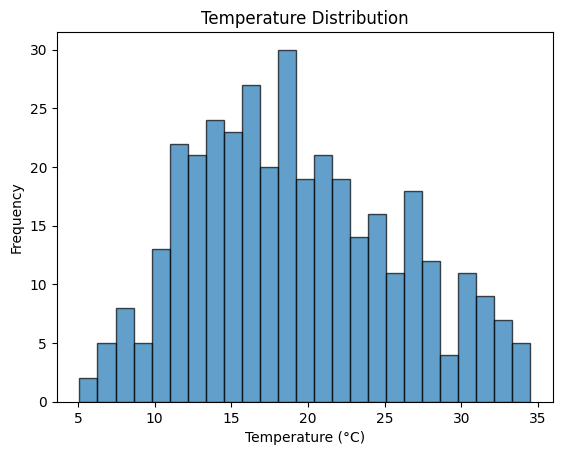

In [11]:
plt.figure()
plt.hist(df['Temp'], bins=25, edgecolor='black', alpha=0.7)
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Temperature Distribution')
plt.show()

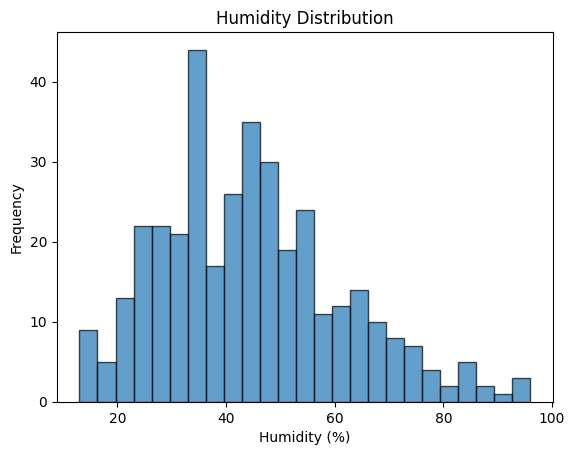

In [12]:
plt.figure()
plt.hist(df['Humidity'], bins=25, edgecolor='black', alpha=0.7)
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')
plt.title('Humidity Distribution')
plt.show()

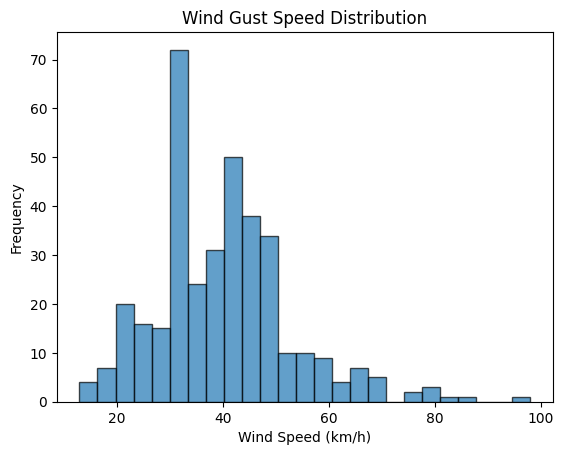

In [13]:
plt.figure()
plt.hist(df['WindGustSpeed'], bins=25, edgecolor='black', alpha=0.7)
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Frequency')
plt.title('Wind Gust Speed Distribution')
plt.show()

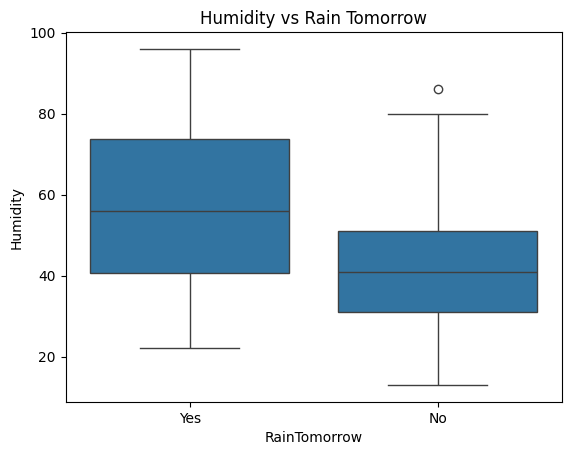

In [14]:
plt.figure()
sns.boxplot(x='RainTomorrow', y='Humidity', data=df)
plt.title('Humidity vs Rain Tomorrow')
plt.show()

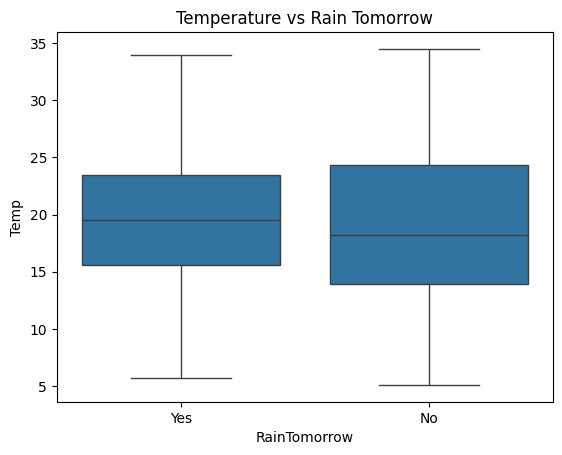

In [15]:
plt.figure()
sns.boxplot(x='RainTomorrow', y='Temp', data=df)
plt.title('Temperature vs Rain Tomorrow')
plt.show()

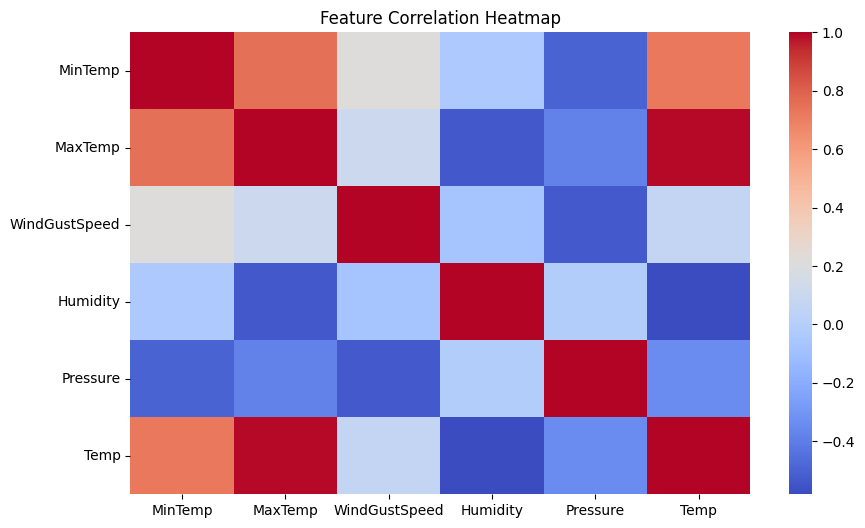

In [17]:
numeric_cols = df.select_dtypes(include=[np.number])
correlation = numeric_cols.corr()


plt.figure(figsize=(10, 6))
sns.heatmap(correlation, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

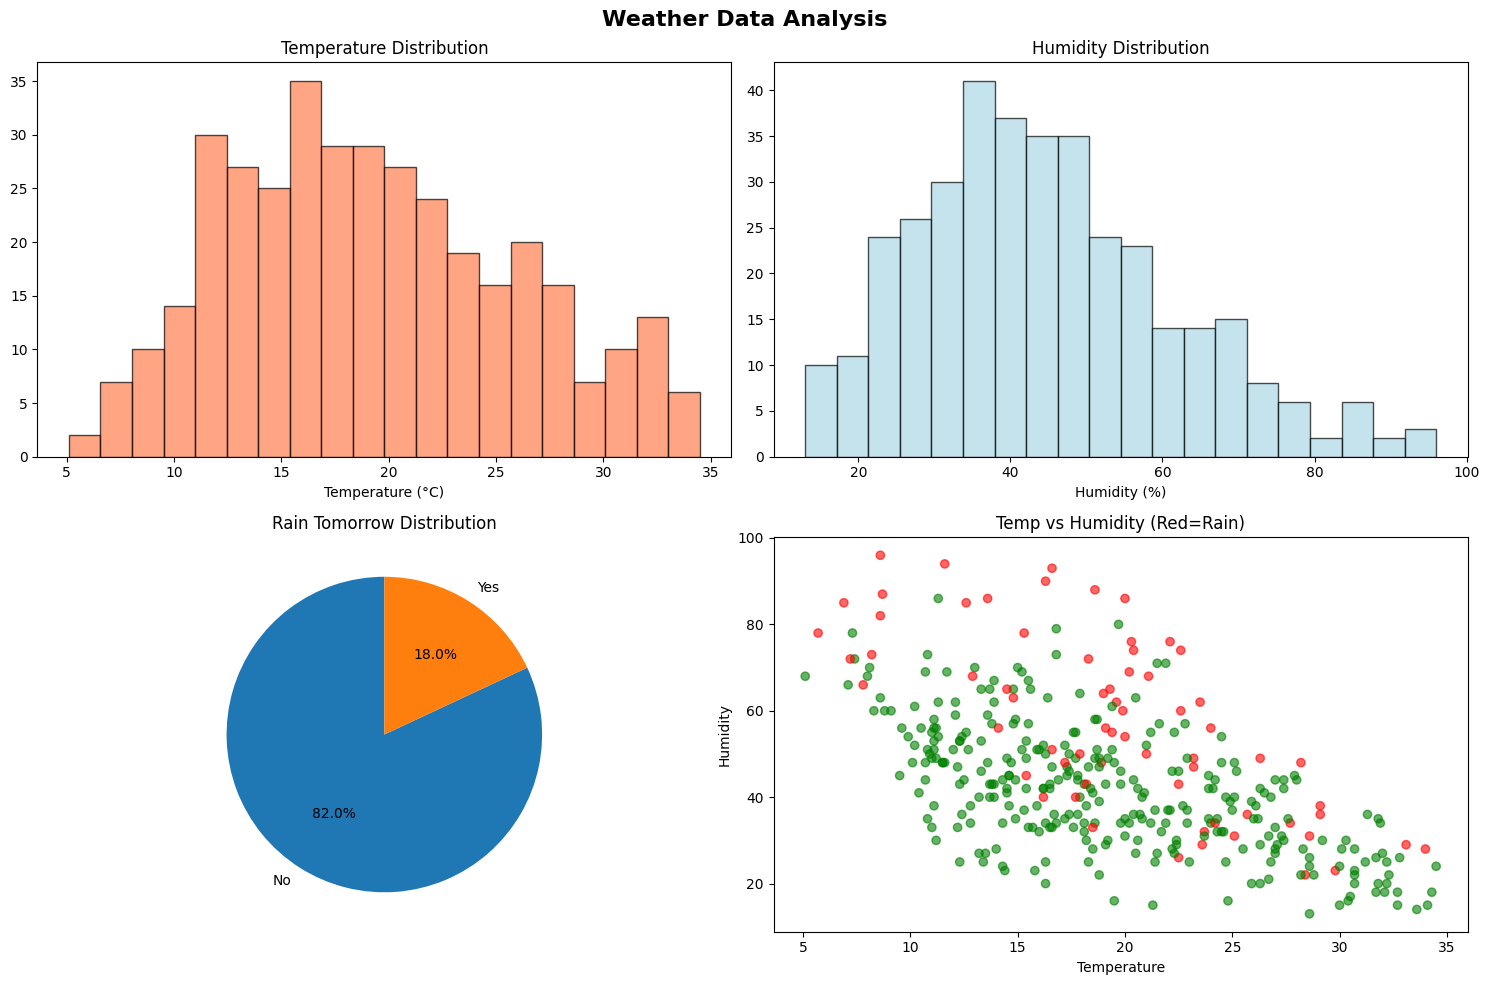

In [19]:
from matplotlib import pyplot as plt
# Weather data distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Weather Data Analysis', fontsize=16, fontweight='bold')

# Temperature distribution
axes[0,0].hist(df['Temp'], bins=20, color='coral', alpha=0.7, edgecolor='black')
axes[0,0].set_title('Temperature Distribution')
axes[0,0].set_xlabel('Temperature (°C)')

# Humidity distribution  
axes[0,1].hist(df['Humidity'], bins=20, color='lightblue', alpha=0.7, edgecolor='black')
axes[0,1].set_title('Humidity Distribution')
axes[0,1].set_xlabel('Humidity (%)')

# Rain vs No Rain
rain_counts = df['RainTomorrow'].value_counts()
axes[1,0].pie(rain_counts.values, labels=rain_counts.index, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Rain Tomorrow Distribution')

# Temp vs Humidity scatter
axes[1,1].scatter(df['Temp'], df['Humidity'], c=df['RainTomorrow'].map({'Yes': 'red', 'No': 'green'}), alpha=0.6)
axes[1,1].set_xlabel('Temperature')
axes[1,1].set_ylabel('Humidity')
axes[1,1].set_title('Temp vs Humidity (Red=Rain)')

plt.tight_layout()
plt.savefig('weather_eda.png', dpi=300, bbox_inches='tight')
plt.show()
